Students name and Students ID:  
- RABOANARY Hasin’Ny Aina Liantsoa | 2510_30693  
- RAZAFINIRINA Nick Kevin | 2510_30690

In [1]:
# import the required packages and modules
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, RobustScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
# load and print the five first obsevation of the dataset
data = pd.read_csv("/content/drive/MyDrive/Unsupervised ML/Datasets/online_shoppers_intention.csv")
data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
# display the dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [ ]:
# display the statistics summary of numerical columns
data.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [ ]:
# get the column names of categorical features
categorical_cols = data.select_dtypes(include=["object", "bool"]).columns
categorical_cols

Index(['Month', 'VisitorType', 'Weekend', 'Revenue'], dtype='object')

In [ ]:
# print the unique values of categorical features
for col in categorical_cols:
    print("Unique values for ", col, ": ", data[col].unique())

Unique values for  Month :  ['Feb' 'Mar' 'May' 'Oct' 'June' 'Jul' 'Aug' 'Nov' 'Sep' 'Dec']
Unique values for  VisitorType :  ['Returning_Visitor' 'New_Visitor' 'Other']
Unique values for  Weekend :  [False  True]
Unique values for  Revenue :  [False  True]


In [ ]:
# check the number of each unique values in Revenue
data["Revenue"].value_counts()

,count
Revenue,
False,10422
True,1908


In [ ]:
# check the number of each unique values in VisitorType
data["VisitorType"].value_counts()

,count
VisitorType,
Returning_Visitor,10551
New_Visitor,1694
Other,85


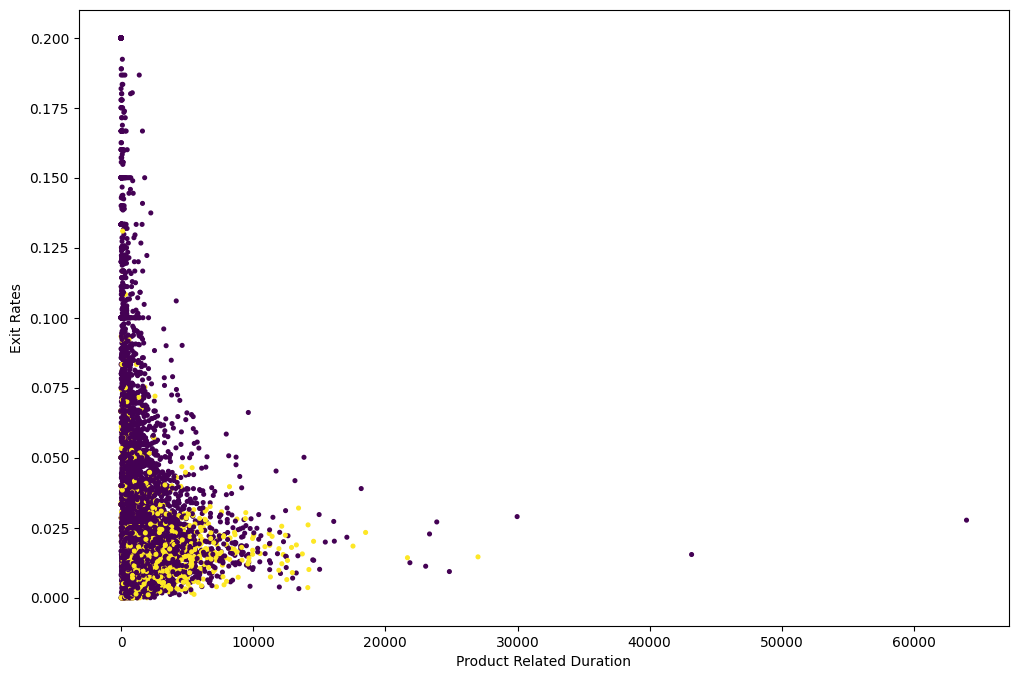

In [ ]:
# Visualise data points based on ProductRelated_Duration and ExitRates

labels = []

for revenue in data["Revenue"]:
    label = 1 if revenue == False else 2
    labels.append(label)

plt.figure(figsize=(12, 8))
plt.scatter(data["ProductRelated_Duration"], data["ExitRates"], c=labels, marker="o", s=7)
plt.xlabel("Product Related Duration")
plt.ylabel("Exit Rates")
plt.show()

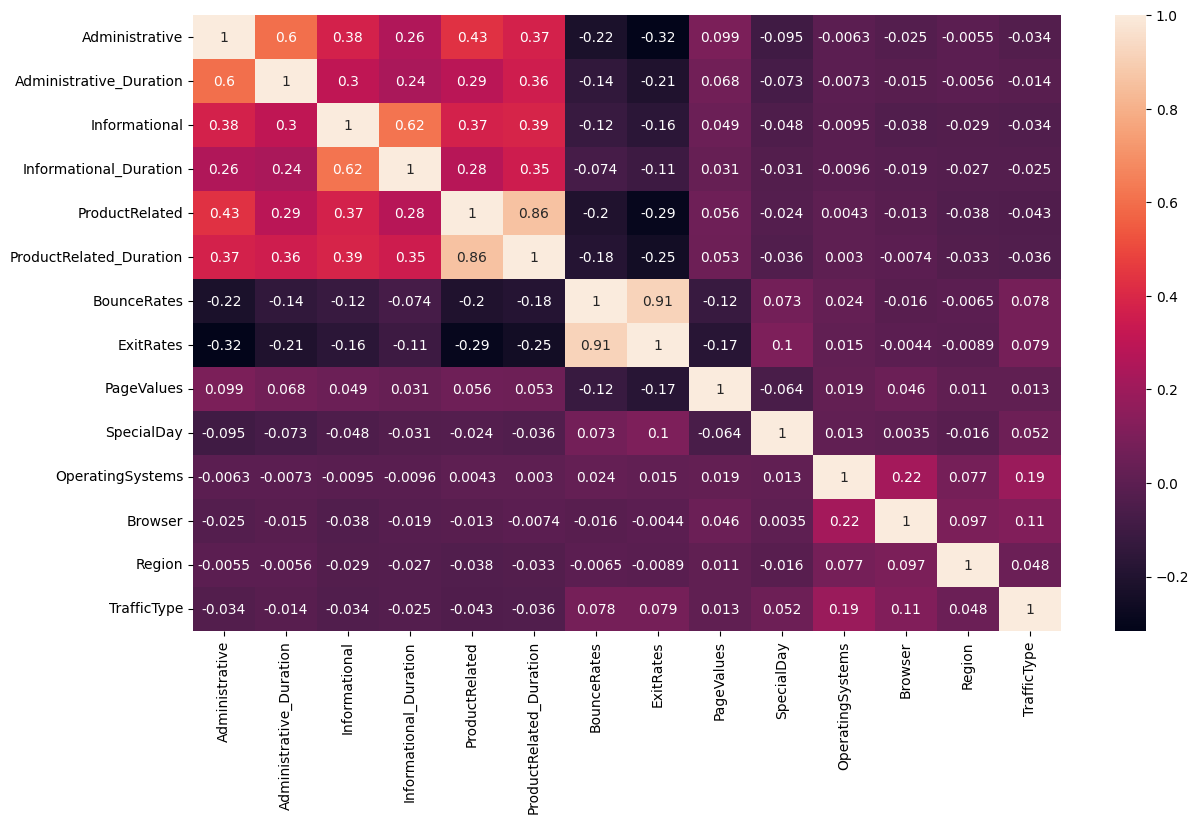

In [ ]:
# plot the correlation heatmap among features
numerical_cols = data.select_dtypes(include=["int64", "float64"])
data_corr = numerical_cols.corr()
plt.figure(figsize=(14, 8))
sns.heatmap(data_corr, annot=True)
plt.show()

In [3]:
# drop on the high correlated features and the non-insigthfull ordinal variables
data.drop(columns=["ProductRelated", "BounceRates", "OperatingSystems", "Browser", "Region", "TrafficType"], inplace=True)
print("Left columns", data.columns)

Left columns Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated_Duration', 'ExitRates',
       'PageValues', 'SpecialDay', 'Month', 'VisitorType', 'Weekend',
       'Revenue'],
      dtype='object')


In [4]:
# get the numerical columns
numerical_data = data.select_dtypes(include=["int64", "float64"])
numerical_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated_Duration,ExitRates,PageValues,SpecialDay
0,0,0.0,0,0.0,0.000000,0.20,0.0,0.0
1,0,0.0,0,0.0,64.000000,0.10,0.0,0.0
2,0,0.0,0,0.0,0.000000,0.20,0.0,0.0
3,0,0.0,0,0.0,2.666667,0.14,0.0,0.0
4,0,0.0,0,0.0,627.500000,0.05,0.0,0.0


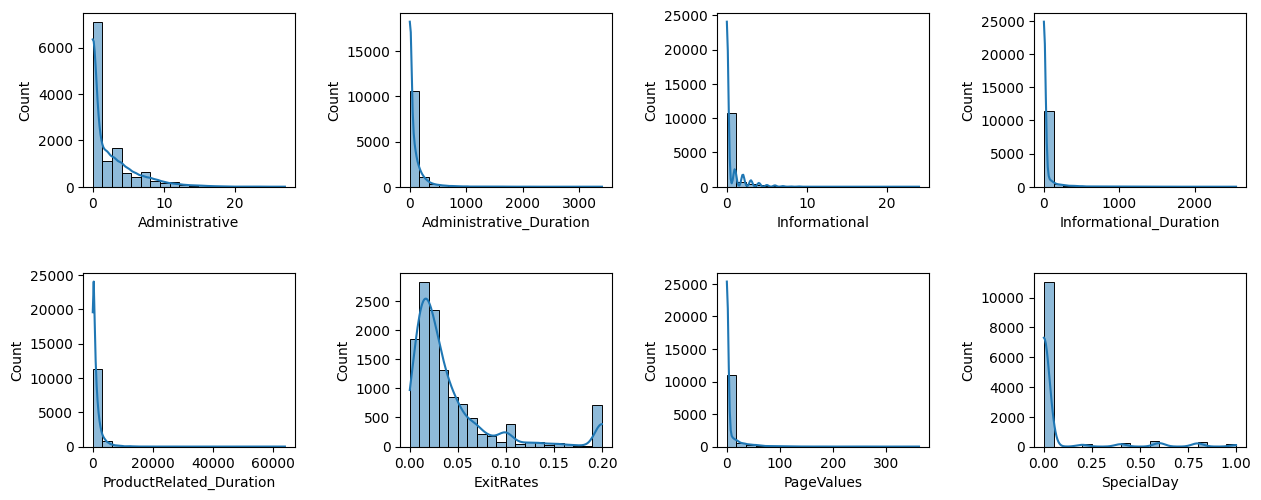

In [ ]:
# display the histogram of each numerical column
num_col = 0
plt.figure(figsize=(15, 9))
for col in numerical_data.columns:
    num_col += 1
    plt.subplot(3, 4, num_col)
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    sns.histplot(numerical_data[col], bins=20, kde=True)
plt.show()

In [5]:
# initialize encoders
bool_enc = OrdinalEncoder(categories=[[False, True]])
one_enc = OneHotEncoder(sparse_output=False)

In [6]:
# encode categorical columns
data["Weekend"] = bool_enc.fit_transform(data[["Weekend"]])
data["Revenue"] = bool_enc.fit_transform(data[["Revenue"]])
visitor_data = one_enc.fit_transform(data[["VisitorType", "Month"]])

In [7]:
# concat the encoded features with the initial data
visitor_df = pd.DataFrame(visitor_data, columns=one_enc.get_feature_names_out(["VisitorType", "Month"]))
encoded_data = pd.concat([data.drop(columns=["VisitorType", "Month", "Revenue"]), visitor_df], axis=1)
encoded_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated_Duration,ExitRates,PageValues,SpecialDay,Weekend,VisitorType_New_Visitor,...,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
0,0,0.0,0,0.0,0.000000,0.20,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0,0.0,64.000000,0.10,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0,0.0,0.000000,0.20,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0,0.0,2.666667,0.14,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0,0.0,627.500000,0.05,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# display the boxplot of each column for a dataframe
def dataframe_boxplot (df):
    col_num = 0
    plt.figure(figsize=(15, 9))
    for col in df.columns:
        col_num += 1
        plt.subplot(3, 4, col_num)
        plt.subplots_adjust(hspace=0.5, wspace=0.5)
        sns.boxplot(df[col])
        plt.title(f"{col} boxplot")
    plt.show()

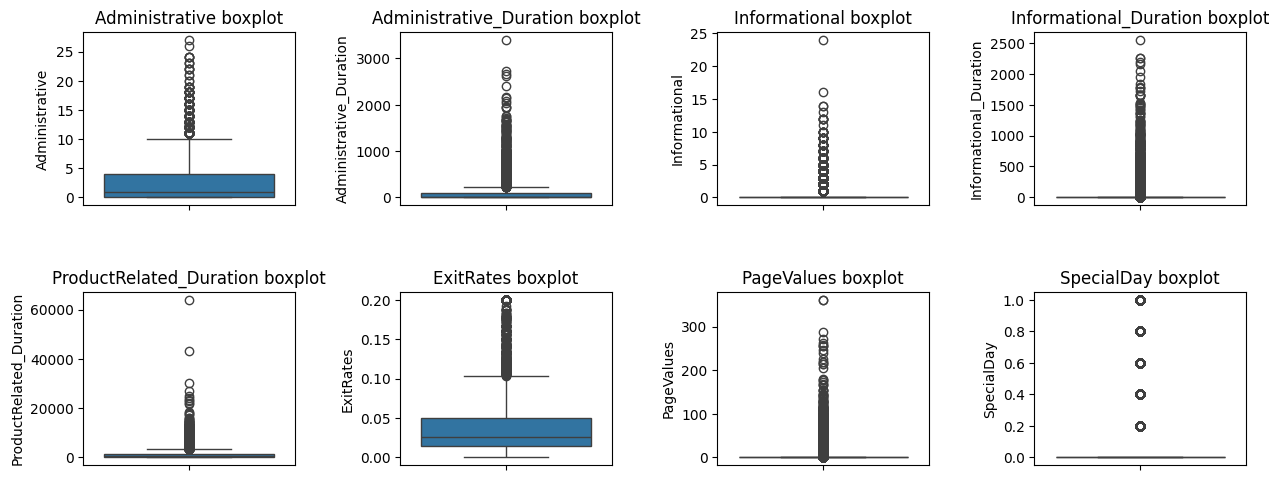

In [ ]:
dataframe_boxplot(numerical_data)

In [8]:
# remove the extreme outliers
no_outliers_num_data = encoded_data[(encoded_data["ProductRelated_Duration"] <= 1465) & (encoded_data["Administrative_Duration"] <= 60) & (encoded_data["Informational_Duration"] <=10)]

In [9]:
# remove missing values if it occurs
no_outliers_num_data = no_outliers_num_data.dropna(axis=1)
no_outliers_num_data.count()

,0
Administrative,6391
Administrative_Duration,6391
Informational,6391
Informational_Duration,6391
ProductRelated_Duration,6391
ExitRates,6391
PageValues,6391
SpecialDay,6391
Weekend,6391
VisitorType_New_Visitor,6391


In [10]:
# initialize the scaler
scaler = StandardScaler()

In [11]:
# standardize the data
scaled_num_data = scaler.fit_transform(no_outliers_num_data)

In [12]:
# initialize PCA with 2 components
pca = PCA(n_components=2, random_state=42)

In [13]:
# reduce the preprocessed data into 2 components
pca_scaled_num_data = pca.fit_transform(scaled_num_data)

In [ ]:
# evaluate the silhouette score for the range of cluster numbers
def evaluate_cluster (data, k):
    n_clusters = range(2, k)

    # implement models in the range
    models = []
    for n in n_clusters:
        gmm = GaussianMixture(n_components=n, random_state=42)
        gmm.fit(data)
        models.append(gmm)

    # store the silhouette score
    scores = []
    for model in models:
        labels = model.predict(data)
        score = silhouette_score(data, labels)
        scores.append(score)

    # plot the scores
    print("k = ", k, "\n", scores, "\n")
    plt.figure(figsize=(8, 5))
    plt.plot(n_clusters, scores, marker="o")
    plt.xlabel("Number of clusters")
    plt.ylabel("Silhouette score")
    plt.title("Cluster evaluation")
    plt.show()

k =  12 
 [np.float64(0.5440694634130209), np.float64(0.5549857609205702), np.float64(0.5077806225420272), np.float64(0.4529517152419889), np.float64(0.3934021644358583), np.float64(0.2652677832305366), np.float64(0.3473087551816852), np.float64(0.29400710028048205), np.float64(0.30108150576621634), np.float64(0.2903491198909404)] 



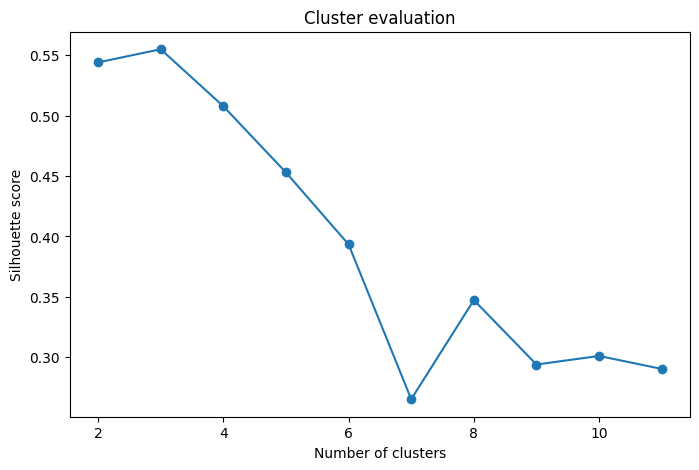

In [ ]:
# evaluate the scores for a range of 2 to 11 clusters
evaluate_cluster(pca_scaled_num_data, 12)

In [14]:
# implement the final model with 3 clusters
gmm_model = GaussianMixture(n_components=3, random_state=42)
labels = gmm_model.fit_predict(pca_scaled_num_data)
no_outliers_num_data["Cluster"] = labels

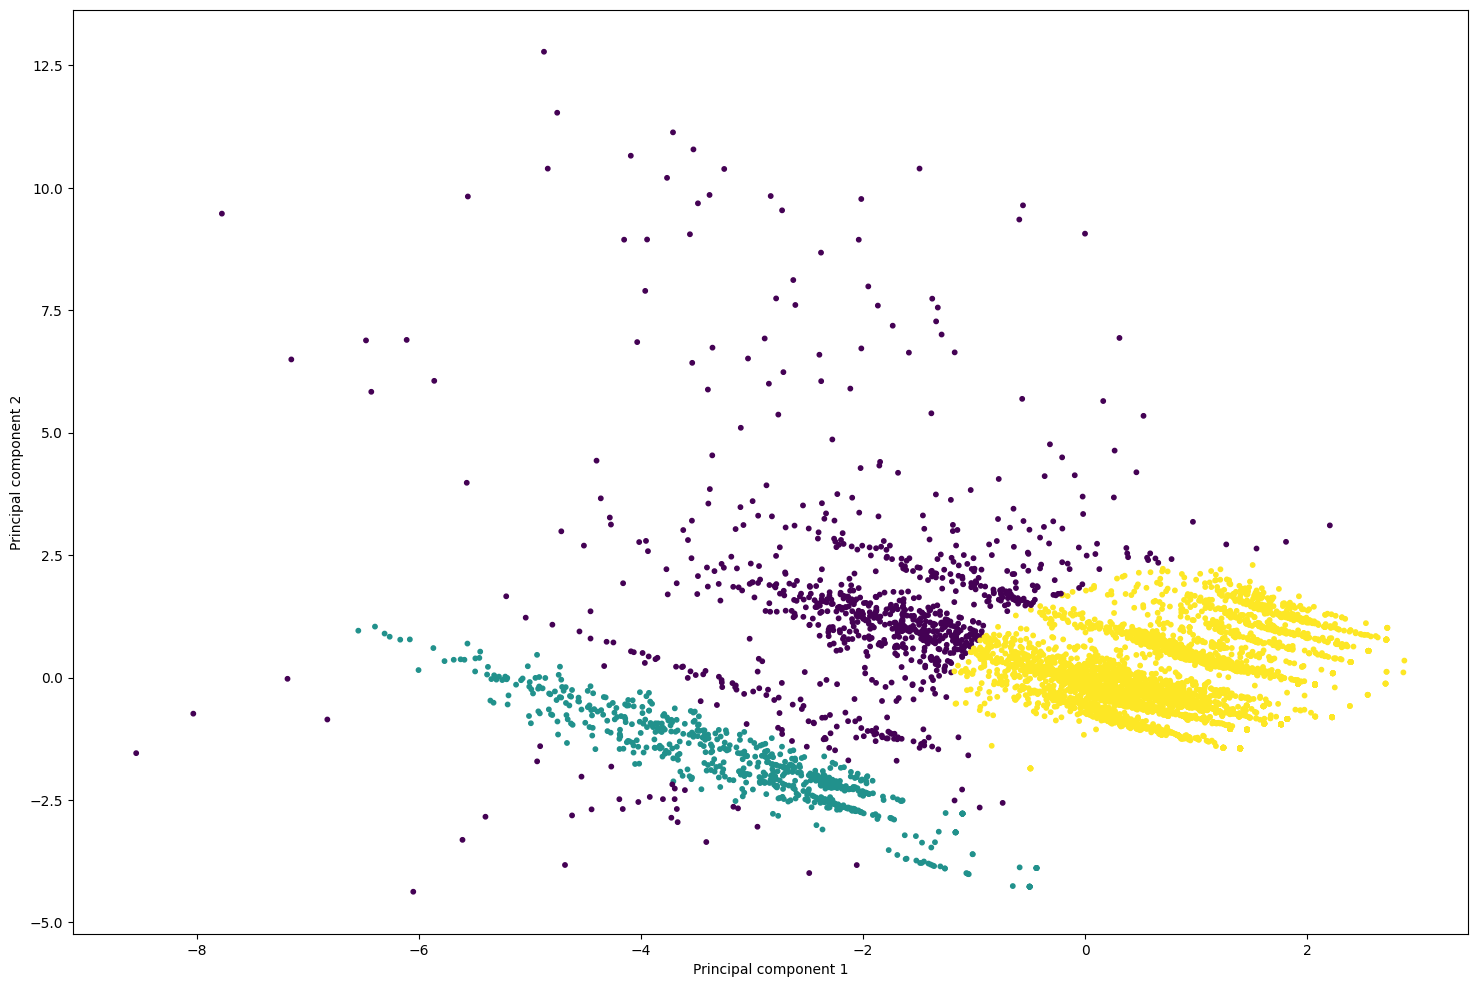

In [15]:
# visualise the clustering result
plt.figure(figsize=(18, 12))
plt.scatter(pca_scaled_num_data[:, 0], pca_scaled_num_data[:, 1], c=labels, s=10)
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.show()

In [ ]:
# check the cluster size
print(no_outliers_num_data["Cluster"].value_counts())

Cluster
2    4795
0     925
1     671
Name: count, dtype: int64


In [ ]:
# display the cluster mean for evaluation
no_outliers_num_data.groupby("Cluster").mean()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated_Duration,ExitRates,PageValues,SpecialDay,Weekend,VisitorType_New_Visitor,...,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.108108,30.017605,0.190270,0.493774,626.899073,0.026791,13.666489,0.063568,0.259459,0.176216,...,0.040000,0.129730,0.004324,0.048649,0.018378,0.120000,0.353514,0.169730,0.057297,0.058378
1,0.962742,13.979190,0.000000,0.000000,380.859010,0.033317,8.351114,0.000000,0.269747,0.928465,...,0.041729,0.305514,0.000000,0.020864,0.014903,0.120715,0.010432,0.339791,0.073025,0.073025
2,0.134307,1.212835,0.003337,0.000000,344.765334,0.072657,1.705715,0.093931,0.200417,0.002294,...,0.024818,0.122002,0.032325,0.033160,0.028989,0.197289,0.332847,0.195203,0.017935,0.015433


In [16]:
with open("one-hot-encoder.pkl", "wb") as file:
    pickle.dump(one_enc, file)

In [17]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [18]:
with open("pca2.pkl", "wb") as file:
    pickle.dump(pca, file)

In [19]:
with open("gmm-model.pkl", "wb") as file:
    pickle.dump(gmm_model, file)